In [4]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
from functions import *
from scipy.stats import ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
import warnings
warnings.filterwarnings('ignore')

In [5]:
dados = pd.read_csv('results/data.csv', index_col='Cluster')
df = pd.read_csv('results/results.csv', index_col ='Cluster')

In [30]:
dados

,pmRApmDEcor,PlxpmRAcor,PlxpmDEcor,Nper,RA_ICRS,e_RA_ICRS,DE_ICRS,e_DE_ICRS,Source,Plx,...,RFBP,RFRP,Pmemb,mass,er_mass,comp_mass,er_comp_mass,q,er_q,r/rh
Cluster,,,,,,,,,,,,,,,,,,,,,
ASCC_10,0.1447,0.1161,0.2402,15,51.784163,0.0213,35.017620,0.0159,221887944772600576,1.5564,...,652.897,1008.836,1.00,2.956492,0.038019,1.678629,0.127743,0.567777,0.043820,0.187365
ASCC_10,-0.0563,0.1867,0.3241,15,51.806881,0.0188,34.944830,0.0128,221886501663608576,1.5485,...,934.599,1197.266,1.00,1.551434,0.008811,0.783902,0.139224,0.505276,0.089785,0.230272
ASCC_10,0.2128,0.3035,0.2494,15,51.780776,0.1005,34.965042,0.0715,221886772245694464,1.3127,...,71.699,195.424,0.98,0.616595,0.000895,0.000000,0.000000,0.000000,NaN,0.254200
ASCC_10,0.2286,0.3448,0.3935,14,51.909307,0.0348,34.914080,0.0267,221883993402704896,1.5884,...,1338.192,1932.475,1.00,1.348327,0.027948,1.256101,0.035919,0.931600,0.032902,0.285066
ASCC_10,0.0851,0.0907,0.2948,15,51.801493,0.0171,35.103201,0.0122,221901860466613248,1.5455,...,1960.810,2766.129,1.00,2.423792,0.020623,1.263529,0.078987,0.521302,0.032889,0.311812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vdBergh_92,-0.0518,-0.0087,0.0336,18,106.399049,0.0167,-11.612863,0.0177,3045822001231252224,0.9202,...,956.914,952.716,0.91,1.538384,0.003962,0.000000,0.061705,0.000000,NaN,2.883688
vdBergh_92,-0.2879,-0.0964,0.0149,17,106.236812,0.0123,-11.166469,0.0145,3046417146256954752,0.9171,...,1179.376,1164.064,1.00,1.668353,0.003669,0.000000,0.127371,0.000000,NaN,2.920085
vdBergh_92,-0.2881,0.1143,-0.3165,17,105.658420,0.1326,-11.495511,0.1649,3046035130386309888,0.8291,...,6.369,5.276,0.57,0.614145,0.011514,0.000000,0.000000,0.000000,NaN,2.932614


# Corte de binárias por dm1/M1 <0.5

In [6]:
mask = (dados['er_mass']/dados['mass']) < 0.5
aux_1 = dados[mask].copy()

df1 = df.copy()
for cluster in df1.index:
    df1.loc[cluster, 'bin_frac'] = bin_frac(aux_1.loc[cluster])
    df1.loc[cluster, 'bin_frac_corr'] = corr_fb_by_similarity(df1, 'bin_frac', cluster)

In [7]:
print(f'Quantidade de sistemas excluidos: {len(data) - len(aux_1)}')

Quantidade de sistemas excluidos: 0


In [8]:
df1[['bin_frac', 'bin_frac_corr']].describe().round(2)

,bin_frac,bin_frac_corr
count,773.00,773.00
mean,0.50,0.43
std,0.13,0.10
min,0.15,0.25
25%,0.41,0.37
50%,0.50,0.42
75%,0.59,0.48
max,0.87,0.81


In [9]:
aux_1[aux_1['q']>0][['q','comp_mass']].describe().round(2)

,q,comp_mass
count,63605.00,63605.00
mean,0.74,1.03
std,0.14,0.80
min,0.34,0.10
25%,0.62,0.67
50%,0.76,0.90
75%,0.87,1.20
max,0.99,30.43


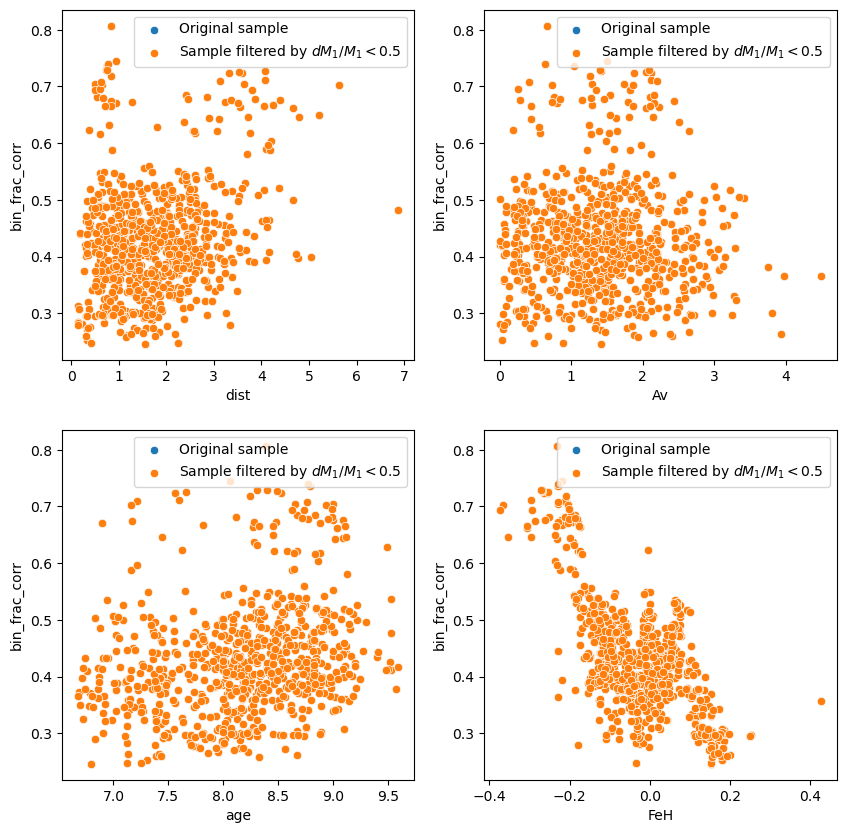

In [10]:
fig, axs = plt.subplots(2,2, figsize = (10,10))
var_ = ['dist', 'Av', 'age', 'FeH']
i, j = 0, 0
for var in var_:
    sns.scatterplot(data=df, x=var, y='bin_frac_corr', ax = axs[i,j], label='Original sample')
    sns.scatterplot(data=df1, x=var, y='bin_frac_corr', ax = axs[i,j], label= r'Sample filtered by $dM_1/M_1 < 0.5$')
    j+=1
    if j>1:
        j=0
        i+=1 
plt.legend()
plt.show()

## Refazer análises com a nova amostra filtrada por $\delta M_1/M_1<0.5$

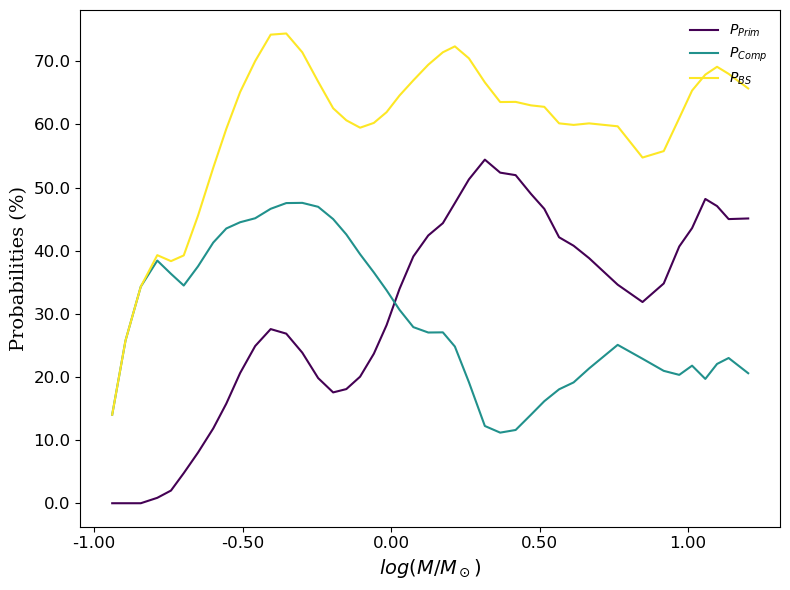

In [11]:
m1 = aux_1['mass'].values
m2 = aux_1['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)


nominal_values = [P_prim, P_comp, P_BS]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']
cmap = plt.cm.viridis
cores = cmap(np.linspace(0, 1, 3))


fig, axs = plt.subplots(figsize=(8,6))

for i in range(0, len(nominal_values)):
    axs.plot(mass_bins,  nominal_values[i]*100,label = labels[i], color = cores[i])    
    
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
axs.set_ylabel(r'Probabilities (%)', fontdict=font)
axs.set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.legend(loc='upper right',frameon=False)
plt.tight_layout()
#plt.savefig('Figures/dist_fb_por_massa2.png', dpi=300)
plt.show()



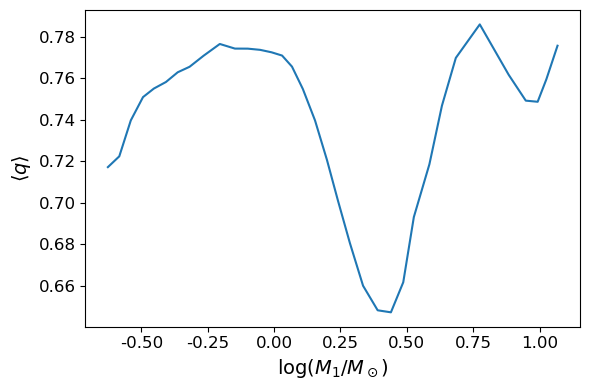

In [12]:
q = m2/m1
log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
plt.show() 



# Corte de binárias por dm2/M2 <0.5

In [13]:
mask = ((dados['er_comp_mass']/dados['comp_mass']) < 0.5) | (dados['comp_mass'] == 0)
aux_2 = dados[mask].copy()

df2 = df.copy()
for cluster in df2.index:
    df2.loc[cluster, 'bin_frac'] = bin_frac(aux_2.loc[cluster])
    df2.loc[cluster, 'bin_frac_corr'] = corr_fb_by_similarity(df2, 'bin_frac', cluster)

In [14]:
print(f'Quantidade de sistemas excluidos: {(len(data) - len(aux_2))}')

Quantidade de sistemas excluidos: 0


In [15]:
aux_2[aux_2['q']>0][['q', 'comp_mass']].describe().round(2)

,q,comp_mass
count,63605.00,63605.00
mean,0.74,1.03
std,0.14,0.80
min,0.34,0.10
25%,0.62,0.67
50%,0.76,0.90
75%,0.87,1.20
max,0.99,30.43


In [16]:
df2[['bin_frac', 'bin_frac_corr']].describe().round(2)

,bin_frac,bin_frac_corr
count,773.00,773.00
mean,0.50,0.43
std,0.13,0.10
min,0.15,0.25
25%,0.41,0.37
50%,0.50,0.42
75%,0.59,0.48
max,0.87,0.81


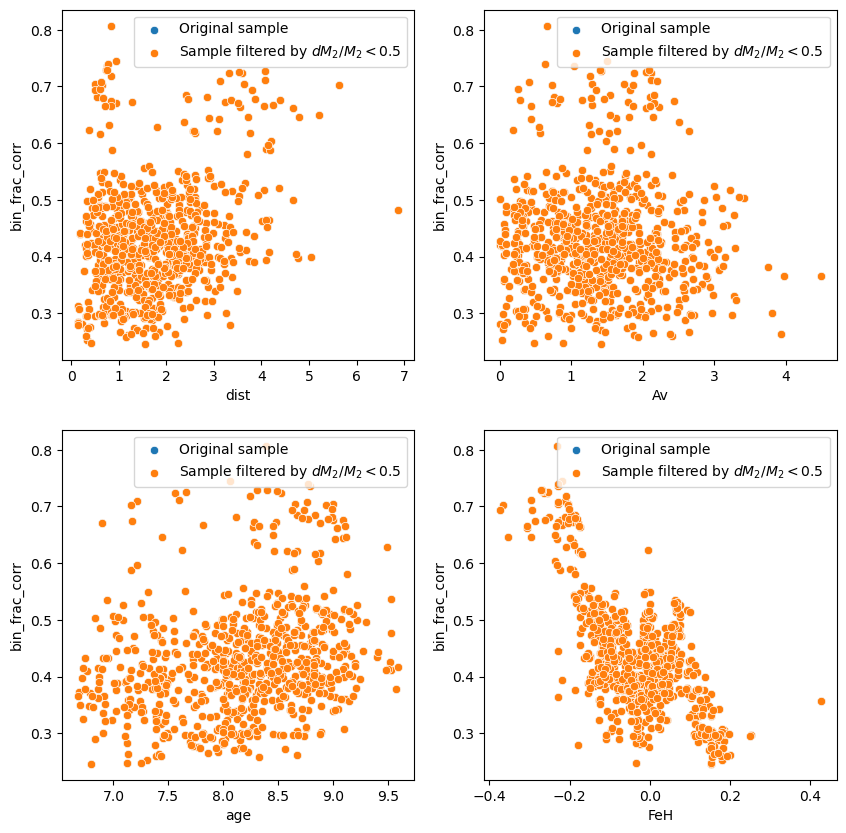

In [17]:
fig, axs = plt.subplots(2,2, figsize = (10,10))
var_ = ['dist', 'Av', 'age', 'FeH']
i, j = 0, 0
for var in var_:
    sns.scatterplot(data=df, x=var, y='bin_frac_corr', ax = axs[i,j], label='Original sample')
    sns.scatterplot(data=df2, x=var, y='bin_frac_corr', ax = axs[i,j], label= r'Sample filtered by $dM_2/M_2 < 0.5$')
    j+=1
    if j>1:
        j=0
        i+=1 
plt.legend()
plt.show()

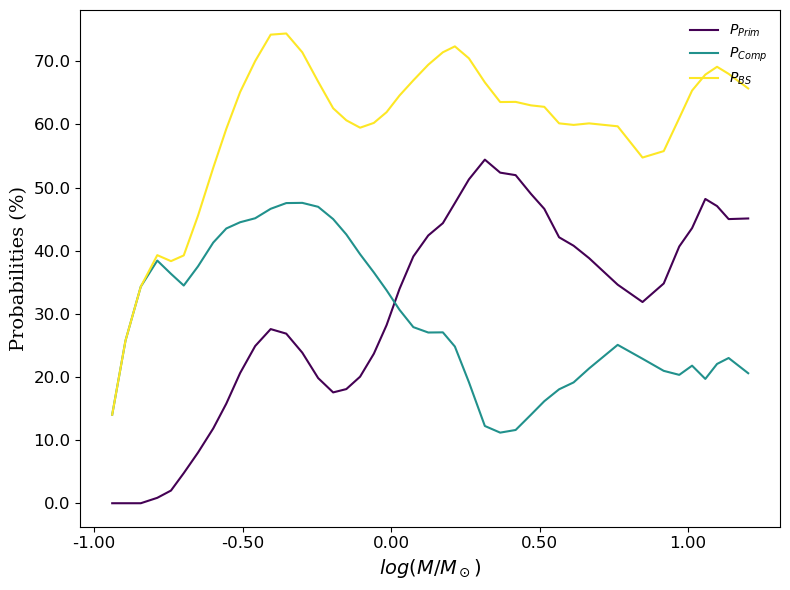

In [18]:
m1 = aux_2['mass'].values
m2 = aux_2['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)


nominal_values = [P_prim, P_comp, P_BS]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']
cmap = plt.cm.viridis
cores = cmap(np.linspace(0, 1, 3))


fig, axs = plt.subplots(figsize=(8,6))

for i in range(0, len(nominal_values)):
    axs.plot(mass_bins,  nominal_values[i]*100,label = labels[i], color = cores[i])    
    
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
axs.set_ylabel(r'Probabilities (%)', fontdict=font)
axs.set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.legend(loc='upper right',frameon=False)
plt.tight_layout()
#plt.savefig('Figures/dist_fb_por_massa2.png', dpi=300)
plt.show()


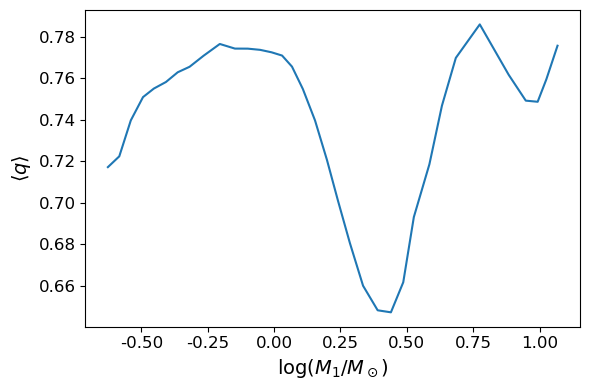

In [19]:
q = m2/m1
log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
plt.show() 


# Corte por $\delta q/q<0.5$

In [20]:
mask = ((data['er_q']/data['q']) <0.5) | (data['q'] == 0)
aux_3 = dados[mask].copy()
df3 = df.copy()
for cluster in df3.index:
    df3.loc[cluster, 'bin_frac'] = bin_frac(aux_3.loc[cluster])
    df3.loc[cluster, 'bin_frac_corr'] = corr_fb_by_similarity(df3, 'bin_frac', cluster)

In [21]:
print(f'Quantidade de sistemas excluidos: {(len(dados) - len(aux_3))}')

Quantidade de sistemas excluidos: 21


In [22]:
aux_3[aux_3['q']>0][['q', 'comp_mass']].describe().round(2)

,q,comp_mass
count,63584.00,63584.00
mean,0.74,1.03
std,0.14,0.80
min,0.34,0.10
25%,0.62,0.67
50%,0.76,0.90
75%,0.87,1.20
max,0.99,30.43


In [23]:
df3[['bin_frac', 'bin_frac_corr']].describe().round(2)

,bin_frac,bin_frac_corr
count,773.00,773.00
mean,0.50,0.43
std,0.13,0.10
min,0.15,0.25
25%,0.41,0.37
50%,0.50,0.42
75%,0.59,0.48
max,0.87,0.81


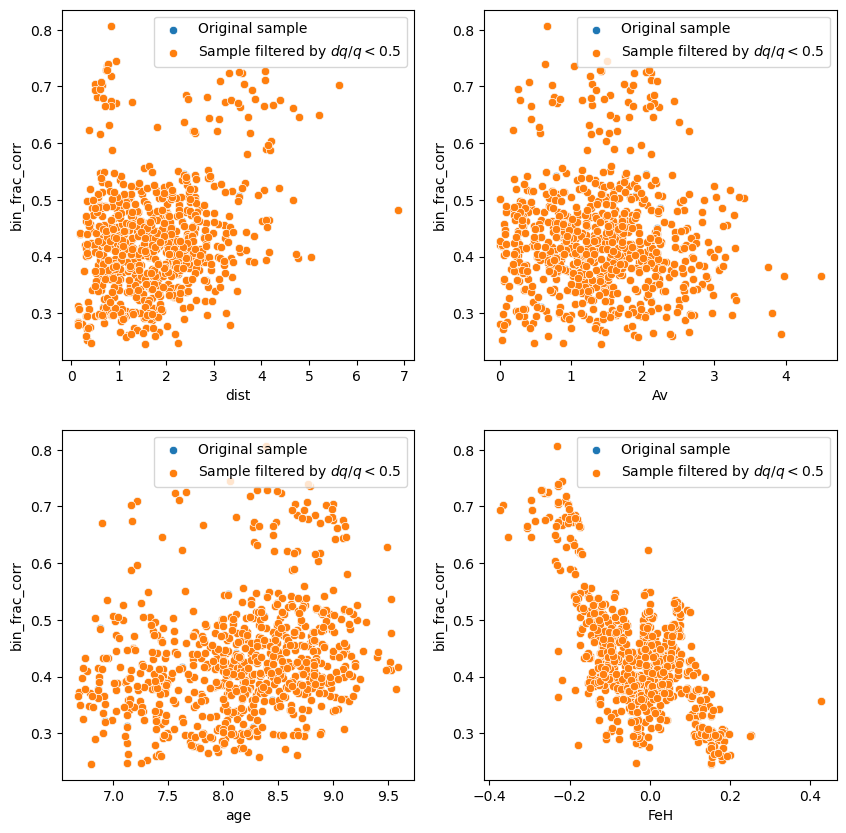

In [24]:
fig, axs = plt.subplots(2,2, figsize = (10,10))
var_ = ['dist', 'Av', 'age', 'FeH']
i, j = 0, 0
for var in var_:
    sns.scatterplot(data=df, x=var, y='bin_frac_corr', ax = axs[i,j], label='Original sample')
    sns.scatterplot(data=df3, x=var, y='bin_frac_corr', ax = axs[i,j], label= r'Sample filtered by $dq/q < 0.5$')
    j+=1
    if j>1:
        j=0
        i+=1 
plt.legend()
plt.show()

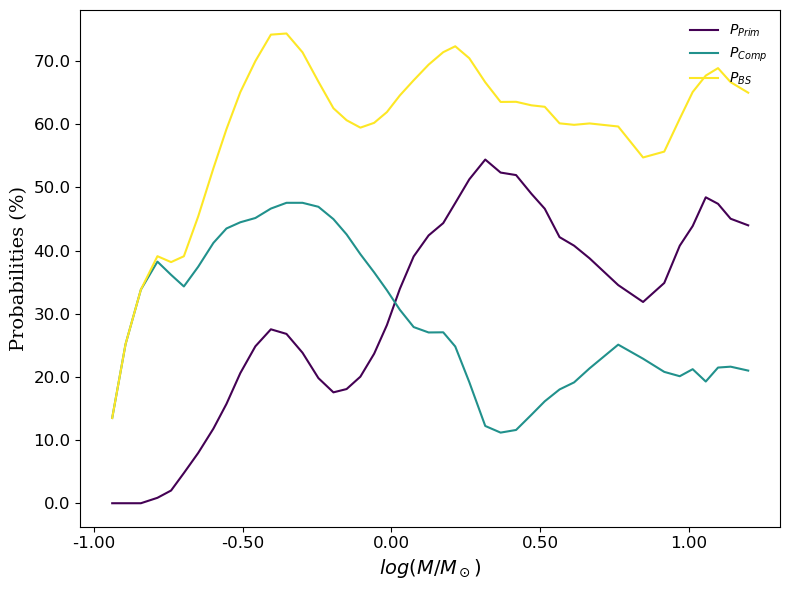

In [25]:
m1 = aux_3['mass'].values
m2 = aux_3['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)


nominal_values = [P_prim, P_comp, P_BS]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']
cmap = plt.cm.viridis
cores = cmap(np.linspace(0, 1, 3))


fig, axs = plt.subplots(figsize=(8,6))

for i in range(0, len(nominal_values)):
    axs.plot(mass_bins,  nominal_values[i]*100,label = labels[i], color = cores[i])    
    
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
axs.set_ylabel(r'Probabilities (%)', fontdict=font)
axs.set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.legend(loc='upper right',frameon=False)
plt.tight_layout()
#plt.savefig('Figures/dist_fb_por_massa2.png', dpi=300)
plt.show()


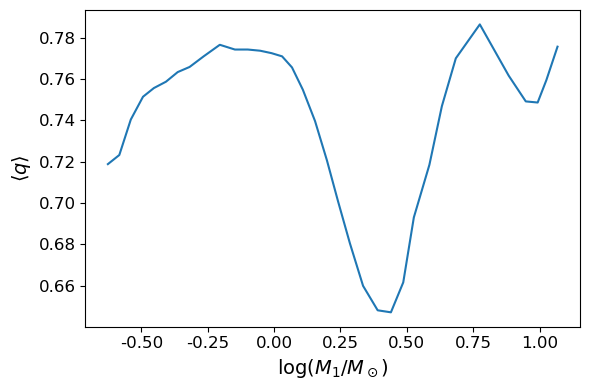

In [26]:
q = m2/m1
log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
plt.show() 


# Comparação dos cortes

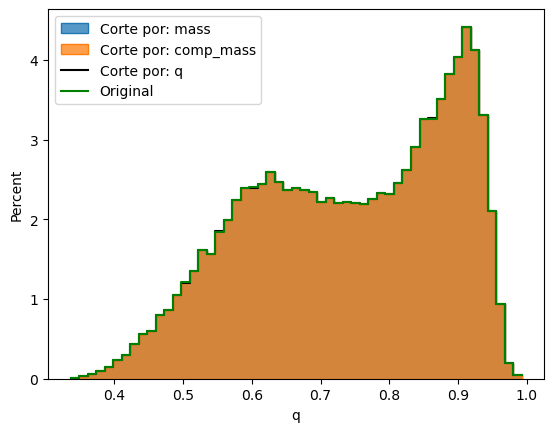

In [27]:
sns.histplot(x = aux_1[aux_1['q']>0]['q'], stat='percent' , element = 'step', label ='Corte por: mass')
sns.histplot(x = aux_2[aux_2['q']>0]['q'], stat='percent' , element = 'step', label ='Corte por: comp_mass')
sns.histplot(x = aux_3[aux_3['q']>0]['q'], stat='percent' , element = 'step', label ='Corte por: q', fill=False, color ='k')
sns.histplot(x = dados[dados['q']>0]['q'], stat='percent' , element = 'step', label ='Original', 
             fill=False, color='green')
plt.legend()
plt.show()

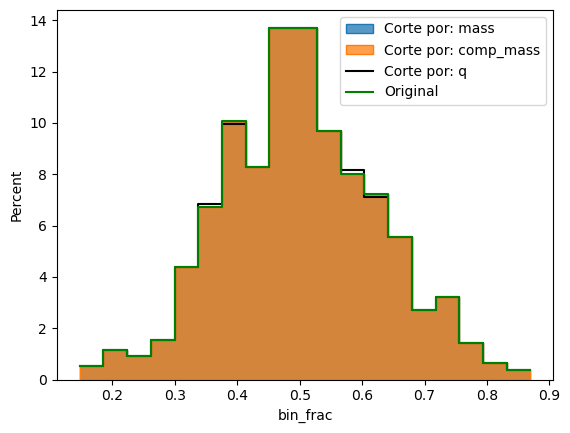

In [28]:
sns.histplot(df1['bin_frac'], stat='percent', element='step', label ='Corte por: mass')
sns.histplot(df2['bin_frac'], stat='percent', element='step', label ='Corte por: comp_mass')
sns.histplot(df3['bin_frac'], stat='percent', element='step', label ='Corte por: q', fill = False, color = 'k')

sns.histplot(x = df['bin_frac'], stat='percent' , element = 'step', label ='Original', 
             fill=False, color='green')
plt.legend()
plt.show()

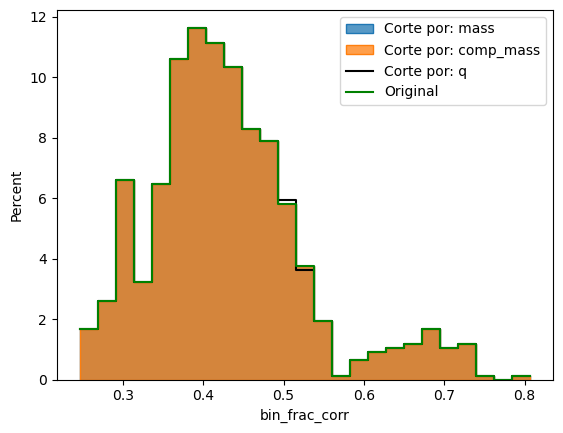

In [29]:
#Distribuição dos valores corrigidos de fb

sns.histplot(df1['bin_frac_corr'], stat='percent', element='step', label ='Corte por: mass')
sns.histplot(df2['bin_frac_corr'], stat='percent', element='step', label ='Corte por: comp_mass')
sns.histplot(df3['bin_frac_corr'], stat='percent', element='step', label ='Corte por: q', fill = False, color = 'k')
sns.histplot(x = df['bin_frac_corr'], stat='percent' , element = 'step', label ='Original', 
             fill=False, color='green')
plt.legend()